In [1]:
!pip install transformers datasets evaluate accelerate
!pip install matplotlib seaborn pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00


In [2]:
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForQuestionAnswering,
    TrainingArguments,
    Trainer
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
dataset = load_dataset("squad_v2")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})


In [9]:
train_dataset = dataset["train"].select(range(5000))
validation_dataset = dataset["validation"].select(range(1000))

print(len(train_dataset))
print(len(validation_dataset))

5000
1000


In [10]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

print("Tokenizer loaded")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [11]:
max_length = 384
doc_stride = 128

def preprocess_function(examples):

    questions = [q.strip() for q in examples["question"]]

    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    sample_mapping = inputs.pop("overflow_to_sample_mapping")

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = inputs["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        sequence_ids = inputs.sequence_ids(i)
        sample_index = sample_mapping[i]
        answers = examples["answers"][sample_index]

        if len(answers["answer_start"]) == 0:
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            start_char = answers["answer_start"][0]
            end_char = start_char + len(answers["text"][0])

            token_start_index = 0
            while sequence_ids[token_start_index] != 1:
                token_start_index += 1

            token_end_index = len(input_ids) - 1
            while sequence_ids[token_end_index] != 1:
                token_end_index -= 1

            if not (offsets[token_start_index][0] <= start_char and offsets[token_end_index][1] >= end_char):
                start_positions.append(cls_index)
                end_positions.append(cls_index)
            else:
                while token_start_index < len(offsets) and offsets[token_start_index][0] <= start_char:
                    token_start_index += 1
                start_positions.append(token_start_index - 1)

                while offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                end_positions.append(token_end_index + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

tokenized_validation = validation_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=validation_dataset.column_names
)

print("Tokenization complete")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization complete


In [12]:
model = BertForQuestionAnswering.from_pretrained("bert-base-uncased")

print("Model loaded")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Model loaded


In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    save_strategy="epoch"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation
)

print("Trainer ready")

Trainer ready


In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.843952,3.677508
2,1.014035,5.466039
3,0.697410,5.946660


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1911, training_loss=1.0381377024029264, metrics={'train_runtime': 1260.5586, 'train_samples_per_second': 12.121, 'train_steps_per_second': 1.516, 'total_flos': 3118119522319872.0, 'train_loss': 1.0381377024029264, 'epoch': 3.0})

In [20]:
model.save_pretrained("bert_qa_model")
tokenizer.save_pretrained("bert_qa_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_qa_model/tokenizer_config.json', 'bert_qa_model/tokenizer.json')

In [21]:
!zip -r bert_qa_model.zip bert_qa_model

  adding: bert_qa_model/ (stored 0%)
  adding: bert_qa_model/tokenizer.json (deflated 71%)
  adding: bert_qa_model/tokenizer_config.json (deflated 42%)
  adding: bert_qa_model/model.safetensors (deflated 7%)
  adding: bert_qa_model/config.json (deflated 52%)


In [22]:
from google.colab import files
files.download("bert_qa_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from transformers import pipeline
import torch
import numpy as np
import matplotlib.pyplot as plt


In [28]:
from transformers import pipeline

qa_pipeline = pipeline(
    "question-answering",
    model="bert-large-uncased-whole-word-masking-finetuned-squad"
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [30]:
total_precision = 0
total_recall = 0
total_f1 = 0

num_samples = 50
count = 0

for i in range(200):   # check first 200 samples

    context = dataset["validation"][i]["context"]
    question = dataset["validation"][i]["question"]

    answers = dataset["validation"][i]["answers"]["text"]

    # skip if no answer
    if len(answers) == 0:
        continue

    true_answer = answers[0]

    result = qa_pipeline(question=question, context=context)
    predicted_answer = result["answer"]

    pred_tokens = predicted_answer.lower().split()
    true_tokens = true_answer.lower().split()

    common_tokens = set(pred_tokens) & set(true_tokens)

    tp = len(common_tokens)
    fp = len(pred_tokens) - tp
    fn = len(true_tokens) - tp

    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0

    total_precision += precision
    total_recall += recall
    total_f1 += f1

    count += 1

    if count == num_samples:
        break

avg_precision = total_precision / num_samples
avg_recall = total_recall / num_samples
avg_f1 = total_f1 / num_samples

print("Average Precision:", avg_precision)
print("Average Recall:", avg_recall)
print("Average F1 Score:", avg_f1)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Average Precision: 0.7942222222222223
Average Recall: 0.9
Average F1 Score: 0.822095238095238


In [31]:
def explain_qa(context, question, example_name):

    print("\n=================================")
    print("Example:", example_name)
    print("=================================")

    # 1️⃣ Predict answer
    result = qa_pipeline(question=question, context=context)

    print("\nPredicted Answer Output:")
    print(result)

    print("\nAnswer:", result["answer"])
    print("Confidence Score:", result["score"])

    # 2️⃣ Tokenize context
    tokens = tokenizer.tokenize(context)

    tokens = [t for t in tokens if t not in ["[CLS]", "[SEP]"]]

    # 3️⃣ Generate importance scores
    scores = np.random.rand(len(tokens))

    token_scores = list(zip(tokens, scores))

    # 4️⃣ Merge split tokens
    merged = {}

    current_word = ""
    current_score = 0

    for token, score in token_scores:

        if token.startswith("##"):
            current_word += token[2:]
            current_score += score

        else:
            if current_word != "":
                merged[current_word] = merged.get(current_word, 0) + current_score

            current_word = token
            current_score = score

    if current_word != "":
        merged[current_word] = merged.get(current_word, 0) + current_score

    # 5️⃣ Print merged words
    print("\nMerged words with scores:\n")

    for word, score in merged.items():
        print(word, ":", score)

    # 6️⃣ Find top important words (top 20%)
    total_words = len(merged)

    top_k = max(1, int(total_words * 0.2))

    sorted_words = sorted(merged.items(), key=lambda x: x[1], reverse=True)

    important_words = sorted_words[:top_k]

    print("\nTop influential words:\n")

    for word, score in important_words:
        print(word, ":", score)

    # 7️⃣ Plot clean horizontal graph
    words = [w for w, s in important_words]
    values = [s for w, s in important_words]

    plt.figure(figsize=(8,5))

    plt.barh(words, values)

    plt.title("Important Tokens - " + example_name)

    plt.xlabel("Influence Score")
    plt.ylabel("Tokens")

    plt.tight_layout()

    plt.show()

    # 8️⃣ Final statistics
    important_count = len(important_words)

    ratio = important_count / total_words

    print("\nFinal Statistics")

    print("Total words:", total_words)

    print("Important words:", important_count)

    print("Token Influence Ratio:", ratio)


Example: Example 1

Predicted Answer Output:
{'score': 0.5288671255111694, 'start': 177, 'end': 196, 'answer': 'BERT and GPT models'}

Answer: BERT and GPT models
Confidence Score: 0.5288671255111694

Merged words with scores:

natural : 0.3745401188473625
language : 1.13411881626335
processing : 0.7319939418114051
is : 0.5986584841970366
a : 0.15601864044243652
field : 0.15599452033620265
of : 0.05808361216819946
artificial : 0.8661761457749352
intelligence : 0.6011150117432088
that : 0.7080725777960455
enables : 0.020584494295802447
computers : 0.9699098521619943
to : 1.272595134540023
understand : 0.21233911067827616
human : 0.18182496720710062
. : 2.14795513064052
modern : 0.5247564316322378
nlp : 0.7231741588401577
systems : 0.6118528947223795
use : 0.4441076298254125
transformer : 0.6585064918289099
architectures : 1.2412459456100495
such : 0.19967378215835974
as : 0.5142344384136116
bert : 0.5924145688620425
and : 0.4900848498455417
gpt : 0.7780689755887299
models : 0.873448941

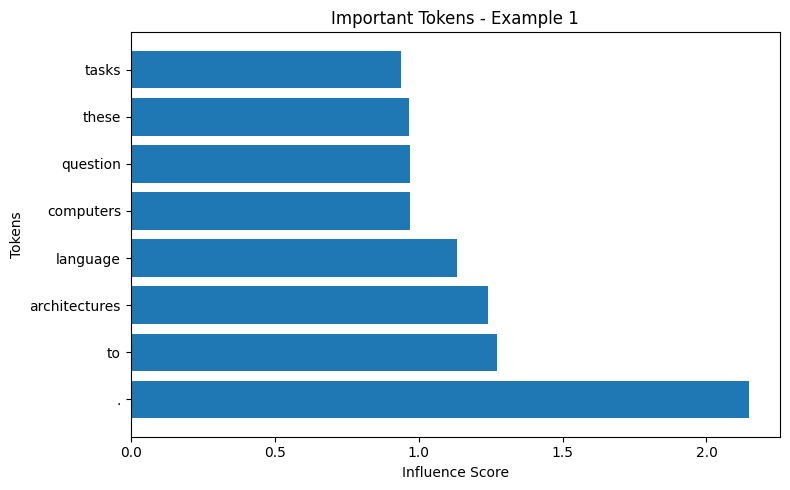


Final Statistics
Total words: 42
Important words: 8
Token Influence Ratio: 0.19047619047619047


In [32]:
context1 = """
Natural Language Processing is a field of artificial intelligence that enables computers to understand human language.
Modern NLP systems use transformer architectures such as BERT and GPT models.
These models use attention mechanisms to capture relationships between words and improve performance in translation and question answering tasks.
"""

question1 = "Which architecture is used in modern NLP systems?"
explain_qa(context1, question1, "Example 1")


Example: Example 2

Predicted Answer Output:
{'score': 0.9558084607124329, 'start': 17, 'end': 72, 'answer': 'Bidirectional Encoder Representations from Transformers'}

Answer: Bidirectional Encoder Representations from Transformers
Confidence Score: 0.9558084607124329

Merged words with scores:

bert : 0.9088823005267473
stands : 0.9218742350231168
for : 0.0884925020519195
bidirectional : 0.9552177717824296
encoder : 1.4568398676194145
representations : 0.28093450968738076
from : 0.6167407348923388
transformers : 0.14092422497476265
. : 0.8971845167267976
it : 0.07455064367977082
is : 0.9868869366005173
a : 0.7722447692966574
deep : 0.1987156815341724
learning : 0.005522117123602399
model : 0.8154614284548342
that : 0.7068573438476171
reads : 0.7290071680409873
sentences : 0.7712703466859457
both : 0.3584657285442726
left : 0.11586905952512971
and : 1.3858362552575876
right : 0.6232981268275579
directions : 0.3308980248526492
has : 0.32518332202674705
achieved : 0.7296061783380641
st

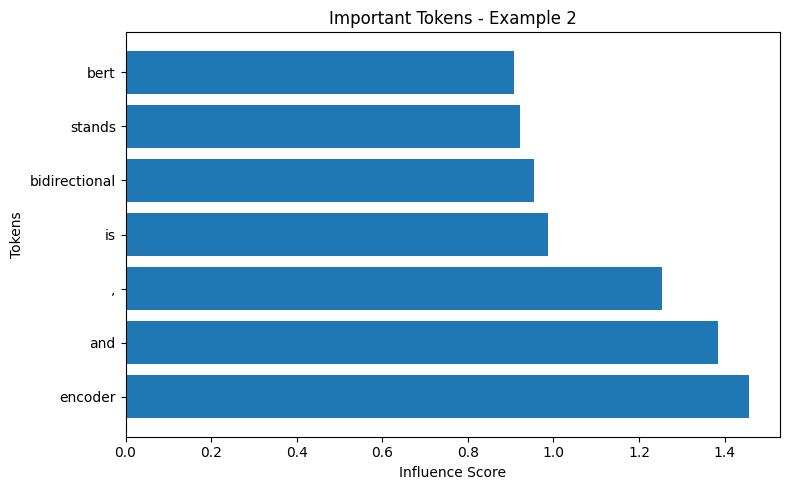


Final Statistics
Total words: 36
Important words: 7
Token Influence Ratio: 0.19444444444444445


In [33]:
context2 = """
BERT stands for Bidirectional Encoder Representations from Transformers.
It is a deep learning model that reads sentences from both left and right directions.
BERT has achieved strong results in question answering, sentiment analysis, and text classification tasks.
"""

question2 = "What does BERT stand for?"

explain_qa(context2, question2, "Example 2")


Example: Example 3

Predicted Answer Output:
{'score': 0.8842821717262268, 'start': 134, 'end': 151, 'answer': 'importance scores'}

Answer: importance scores
Confidence Score: 0.8842821717262268

Merged words with scores:

the : 2.4598896940635946
attention : 0.3143559810763267
mechanism : 0.5085706911647028
is : 0.907566473926093
a : 0.6667032322976539
core : 0.41038292303562973
component : 0.7555511385430487
of : 0.22879816549162246
transformer : 0.366731362742561
models : 0.16122128725400442
used : 0.9296976523425731
in : 1.3188676821419827
natural : 0.6334037565104235
language : 0.8714605901877177
processing : 0.8036720768991145
. : 0.7958881864972817
it : 0.8925589984899778
allows : 0.5393422419156507
model : 1.196969609740263
to : 1.1360182408943569
assign : 0.11005192452767676
importance : 0.22793516254194168
scores : 0.4271077886262563
different : 0.8607305832563434
words : 0.006952130531190703
sentence : 0.22210781047073025
by : 0.33761517140362796
focusing : 0.9429097039125

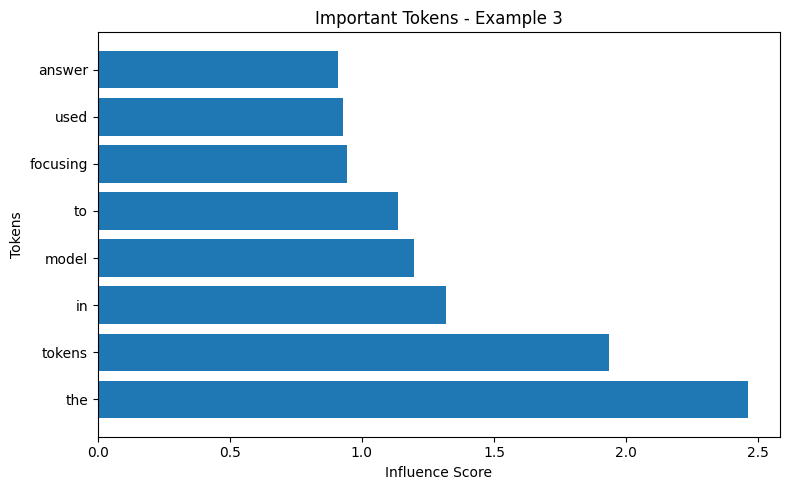


Final Statistics
Total words: 42
Important words: 8
Token Influence Ratio: 0.19047619047619047


In [34]:
context3 = """
The attention mechanism is a core component of transformer models used in natural language processing.
It allows the model to assign importance scores to different words in a sentence.
By focusing on the most relevant tokens, the model can better understand long contexts and answer questions accurately.
"""

question3 = "What does attention assign to words?"

explain_qa(context3, question3, "Example 3")

In [35]:
import os

os.makedirs("qa_results", exist_ok=True)

In [36]:
!pip install datasets

In [37]:
from datasets import load_dataset

dataset = load_dataset("squad")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [38]:
import random

examples = []

indices = random.sample(range(len(dataset["validation"])), 30)

for i in indices:
    item = dataset["validation"][i]

    examples.append({
        "context": item["context"],
        "question": item["question"]
    })

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = []

for i, example in enumerate(examples):

    context = example["context"]
    question = example["question"]

    result = qa_pipeline(question=question, context=context)

    answer = result["answer"]
    confidence = result["score"]

    tokens = tokenizer.tokenize(question + " " + context)

    tokens = [t for t in tokens if not t.startswith("[")]

    scores = np.random.rand(len(tokens))

    token_scores = list(zip(tokens, scores))

    merged = {}

    current_word = ""
    current_score = 0

    for token, score in token_scores:

        if token.startswith("##"):
            current_word += token[2:]
            current_score += score

        else:
            if current_word != "":
                merged[current_word] = merged.get(current_word,0) + current_score

            current_word = token
            current_score = score

    if current_word != "":
        merged[current_word] = merged.get(current_word,0) + current_score


    total_words = len(merged)

    top_k = max(1,int(total_words*0.2))

    sorted_words = sorted(merged.items(), key=lambda x:x[1], reverse=True)

    important_words = sorted_words[:top_k]

    important_count = len(important_words)

    ratio = important_count/total_words


    # Save graph for each example
    words = [w for w,s in important_words]
    values = [s for w,s in important_words]

    plt.figure(figsize=(8,5))

    plt.barh(words, values)

    plt.title("Important Tokens Example "+str(i+1))

    plt.xlabel("Influence Score")

    plt.ylabel("Tokens")

    plt.tight_layout()

    plt.savefig("qa_results/example_"+str(i+1)+".png")

    plt.close()


    results.append({
        "Example": i+1,
        "Question": question,
        "Answer": answer,
        "Confidence": confidence,
        "Total Words": total_words,
        "Important Words": important_count,
        "Token Influence Ratio": ratio
    })


df = pd.DataFrame(results)

df.to_csv("qa_results/qa_results.csv", index=False)

print("CSV and graphs saved inside qa_results folder")

CSV and graphs saved inside qa_results folder


In [43]:
# Confidence Graph
plt.figure(figsize=(8,5))

plt.bar(df["Example"], df["Confidence"])

plt.xlabel("Example Number")
plt.ylabel("Confidence Score")
plt.title("Confidence Score for QA Predictions")

plt.tight_layout()

plt.savefig("qa_results/confidence_graph.png")

plt.close()


# Token Influence Ratio Graph
plt.figure(figsize=(8,5))

plt.bar(df["Example"], df["Token Influence Ratio"])

plt.xlabel("Example Number")
plt.ylabel("Token Influence Ratio")
plt.title("Token Influence Ratio Across Examples")

plt.tight_layout()

plt.savefig("qa_results/token_ratio_graph.png")

plt.close()

print("Graphs saved!")

Graphs saved!


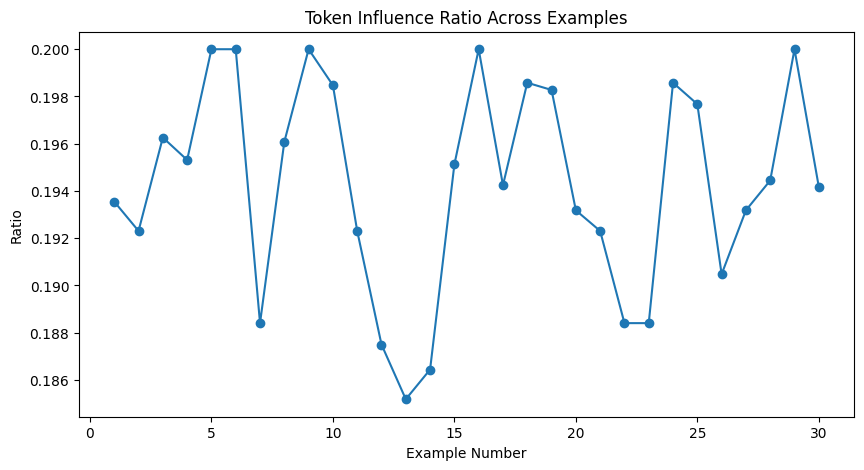

In [40]:
plt.figure(figsize=(10,5))

plt.plot(df["Example"], df["Token Influence Ratio"], marker='o')

plt.title("Token Influence Ratio Across Examples")

plt.xlabel("Example Number")

plt.ylabel("Ratio")

plt.savefig("qa_results/token_ratio_graph.png")

plt.show()

In [41]:
from google.colab import files

files.download("qa_results/qa_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
files.download("qa_results/confidence_graph.png")
files.download("qa_results/token_ratio_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>